# Fraud Detection in Financial Transactions
### Business Analytics Project | PaySim Synthetic Dataset

## Objective

The objective of this project is to build a machine learning model that can accurately detect fraudulent transactions in mobile money systems. 

With the rapid growth of digital payments, especially post-COVID, financial fraud has increased significantly. This project aims to:
- Identify patterns associated with fraudulent transactions
- Build predictive models to classify fraud vs non-fraud
- Optimize detection to minimize financial loss while reducing false positives

## Introduction

The rise of digital financial services has made transactions faster and more accessible, but it has also increased exposure to fraud. Detecting fraudulent transactions is a critical challenge for financial institutions.

This project uses a synthetic dataset generated by PaySim to simulate real-world mobile money transactions. The dataset includes both normal and fraudulent behaviors, enabling the development of fraud detection models.

The goal is to leverage data analysis and machine learning techniques to identify suspicious activities and improve fraud prevention systems.

## Import Libraries & Dependencies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_recall_curve,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import fbeta_score
pd.set_option('display.float_format', '{:.6f}'.format)

## Dataset Description

- Dataset: Synthetic Financial Dataset (PaySim)
- Transactions simulated over 30 days (744 hours)
- Contains ~24 million records (scaled down version)

### Features:
- step: Time step (1 step = 1 hour)
- type: Transaction type (CASH-IN, CASH-OUT, etc.)
- amount: Transaction amount
- nameOrig: Sender
- oldbalanceOrg / newbalanceOrig: Sender balances
- nameDest: Receiver
- oldbalanceDest / newbalanceDest: Receiver balances
- isFraud: Fraud indicator (Target variable)
- isFlaggedFraud: Flag for large suspicious transactions

**Key Note:** Balance columns (oldbalanceOrg, newbalanceOrig, etc.) are zeroed out 
  for fraud transactions by design — they must be dropped to prevent data leakage.

## Data Loading

In [2]:
df=pd.read_csv("/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.640000,C1231006815,170136.000000,160296.360000,M1979787155,0.000000,0.000000,0,0
1,1,PAYMENT,1864.280000,C1666544295,21249.000000,19384.720000,M2044282225,0.000000,0.000000,0,0
2,1,TRANSFER,181.000000,C1305486145,181.000000,0.000000,C553264065,0.000000,0.000000,1,0
3,1,CASH_OUT,181.000000,C840083671,181.000000,0.000000,C38997010,21182.000000,0.000000,1,0
4,1,PAYMENT,11668.140000,C2048537720,41554.000000,29885.860000,M1230701703,0.000000,0.000000,0,0


## Data Understanding & Integrity Check


In [3]:
df.shape

(6362620, 11)

In [4]:
df.columns



Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:

df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.000000,6362620.000000,6362620.000000,6362620.000000,6362620.000000,6362620.000000,6362620.000000,6362620.000000
mean,243.397246,179861.903549,833883.104074,855113.668579,1100701.666520,1224996.398202,0.001291,0.000003
std,142.331971,603858.231463,2888242.673007,2924048.502971,3399180.112969,3674128.942094,0.035905,0.001586
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,156.000000,13389.570000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,239.000000,74871.940000,14208.000000,0.000000,132705.665000,214661.440000,0.000000,0.000000
75%,335.000000,208721.477500,107315.175000,144258.410000,943036.707500,1111909.250000,0.000000,0.000000
max,743.000000,92445516.640000,59585040.370000,49585040.370000,356015889.350000,356179278.920000,1.000000,1.000000


In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

### Fraud Class Distribution

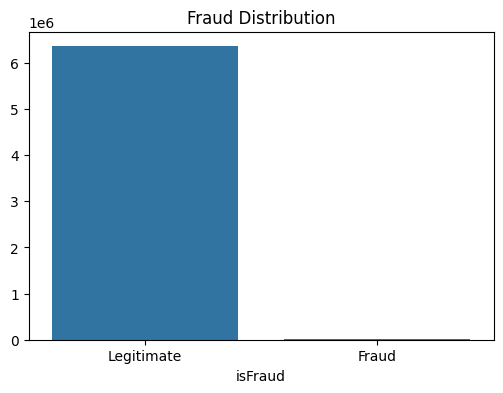

isFraud
0    6354407
1       8213
Name: count, dtype: int64
isFraud
0   99.870918
1    0.129082
Name: count, dtype: float64


In [9]:
fraud_counts = df['isFraud'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values)
plt.title("Fraud Distribution")
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.show()
print(fraud_counts)
print((fraud_counts / len(df) * 100))

#### insights
Legitimate transactions: ~6.35 million (99.87%)
Fraud transactions: ~8,213 (0.13%)

👉 The dataset is extremely imbalanced

### Transaction Type Distribution

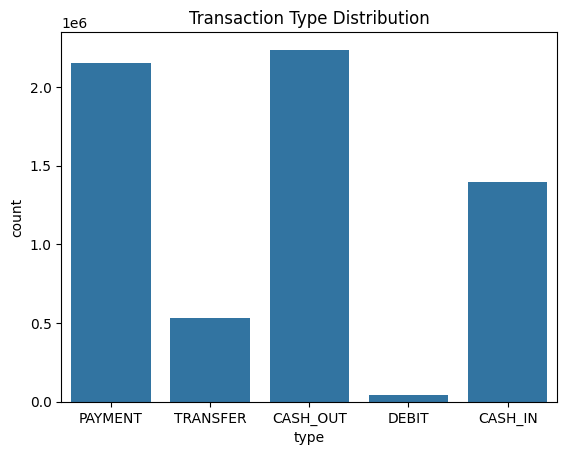

In [10]:
sns.countplot(x=df['type'])
plt.title("Transaction Type Distribution")
plt.show()

#### Insights
The dataset is dominated by CASH_OUT, PAYMENT, and CASH_IN transactions

### Fraud by Transaction Type

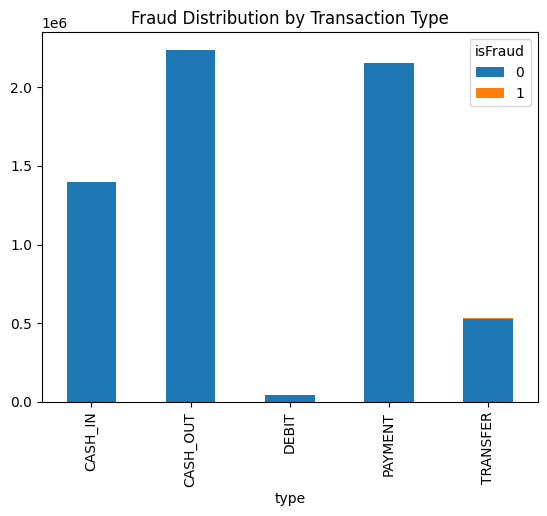

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [11]:
pd.crosstab(df['type'], df['isFraud']).plot(kind='bar', stacked=True)
plt.title("Fraud Distribution by Transaction Type")
plt.show()
pd.crosstab(df['type'], df['isFraud'])

#### Insights 
Fraud occurs ONLY in:TRANSFER,CASH_OUT

TRANSFER frauds: 4097
CASH_OUT frauds: 4116

### Transaction Amount Analysis


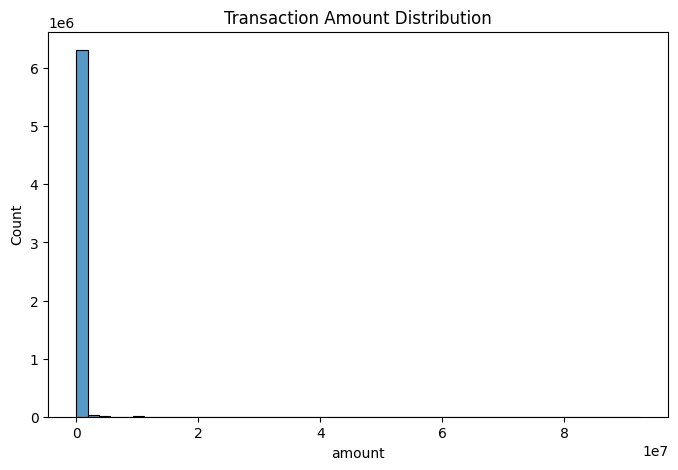

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

#### Insights
The distribution is highly right-skewed
Most users perform small daily transactions

###  Fraud vs Non Fraud — Amount Comparison

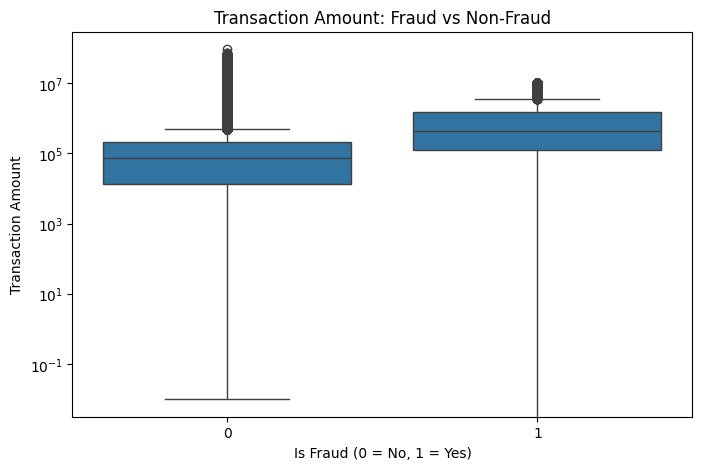

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x='isFraud', y='amount', data=df)

plt.yscale('log')  # important for skewed data
plt.title("Transaction Amount: Fraud vs Non-Fraud")

plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Transaction Amount")

plt.show()

#### Insights
Fraud transactions (isFraud = 1) generally have:
 Higher transaction amounts
 Non-fraud transactions spread across lower and medium ranges.
Fraud shows Higher median and More concentration in high-value range

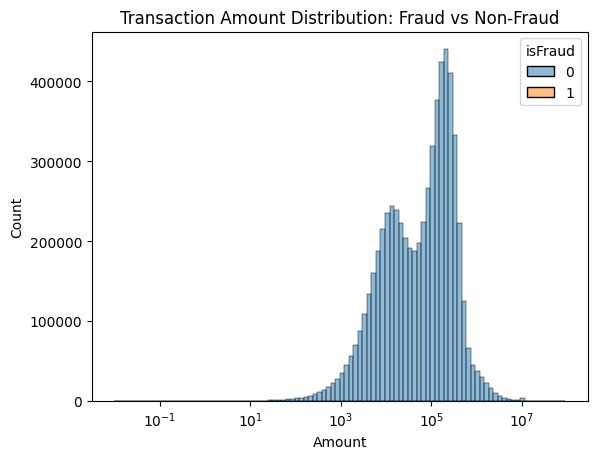

In [14]:
sns.histplot(
    data=df,
    x='amount',
    hue='isFraud',   # separates fraud vs non-fraud
    bins=100,
    log_scale=True   # handles skewed data
)

plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()

### TIME-BASED ANALYSIS

In [15]:
df['hour_of_day'] = ((df['step'] - 1) % 24) + 1
df['day_of_month'] = (df['step'] - 1) // 24 + 1

#### Fraud by Hour

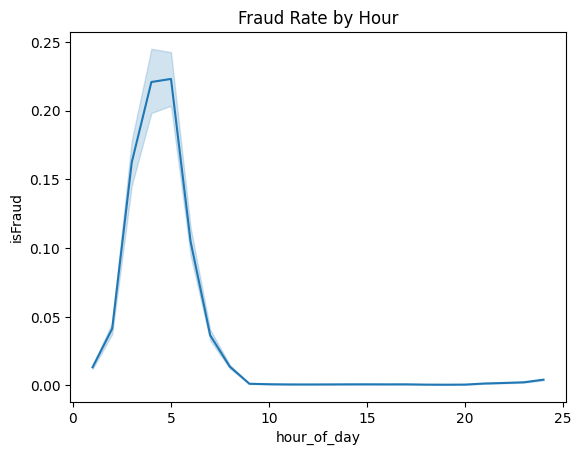

In [16]:
sns.lineplot(x='hour_of_day', y='isFraud', data=df)
plt.title("Fraud Rate by Hour")
plt.show()

#### Insights
Fraud rate peaks sharply between ~3 AM to 6 AM
Maximum fraud around:

👉 4–5 AM


Fraud is:


👉 Almost negligible during daytime hours

#### Fraud by Day

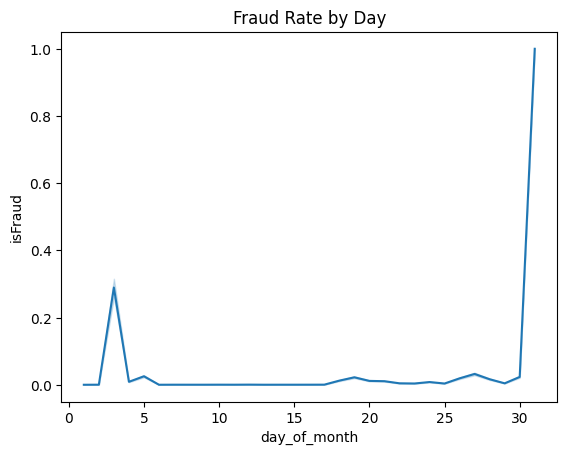

In [17]:
sns.lineplot(x='day_of_month', y='isFraud', data=df)
plt.title("Fraud Rate by Day")
plt.show()

### Balance Analysis

In [18]:
balance_cols = [
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest'
]

df[balance_cols].describe()

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,6362620.000000,6362620.000000,6362620.000000,6362620.000000
mean,833883.104074,855113.668579,1100701.666520,1224996.398202
std,2888242.673007,2924048.502971,3399180.112969,3674128.942094
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,14208.000000,0.000000,132705.665000,214661.440000
75%,107315.175000,144258.410000,943036.707500,1111909.250000
max,59585040.370000,49585040.370000,356015889.350000,356179278.920000


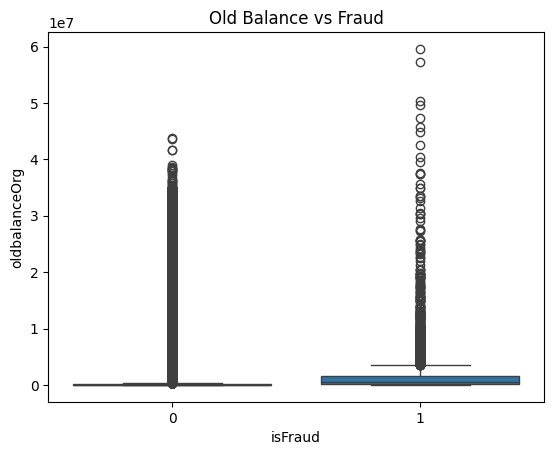

In [19]:

sns.boxplot(x='isFraud', y='oldbalanceOrg', data=df)
plt.title("Old Balance vs Fraud")
plt.show()

### Flagged Fraud vs Actual Fraud

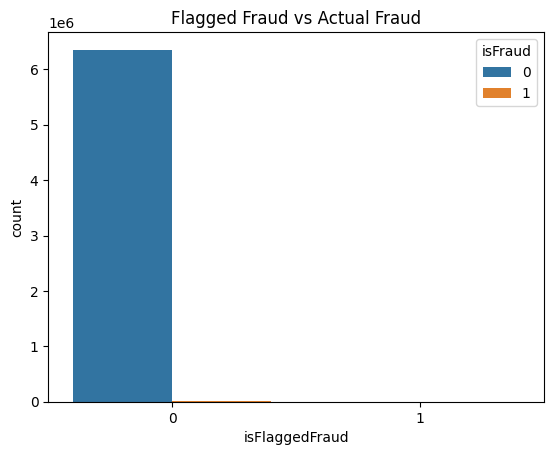

In [20]:
sns.countplot(x='isFlaggedFraud', hue='isFraud', data=df)
plt.title("Flagged Fraud vs Actual Fraud")
plt.show()

### Fraud by Transaction Amount Bucket


In [21]:
df['amount_bucket'] = pd.cut(
    df['amount'],
    bins=[0, 1000, 10000, 100000, 1000000, float('inf')],
    labels=['<1K', '1K-10K', '10K-100K', '100K-1M', '>1M']
)

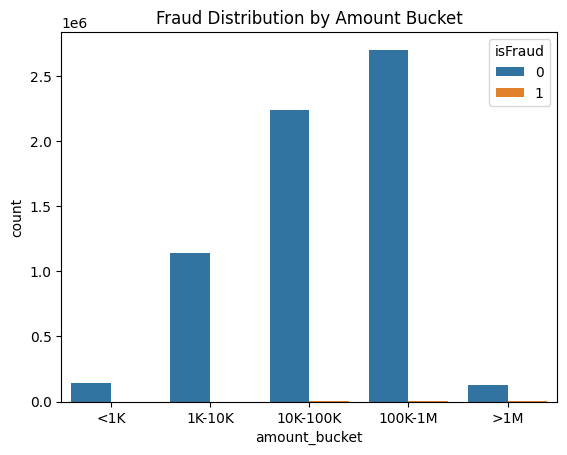

In [22]:
sns.countplot(x='amount_bucket', hue='isFraud', data=df)
plt.title("Fraud Distribution by Amount Bucket")
plt.show()

#### Insights
Fraud is almost non-existent in low-value transactions


Fraud is most concentrated in 100K–1M and >1M buckets



### Correlation Analysis

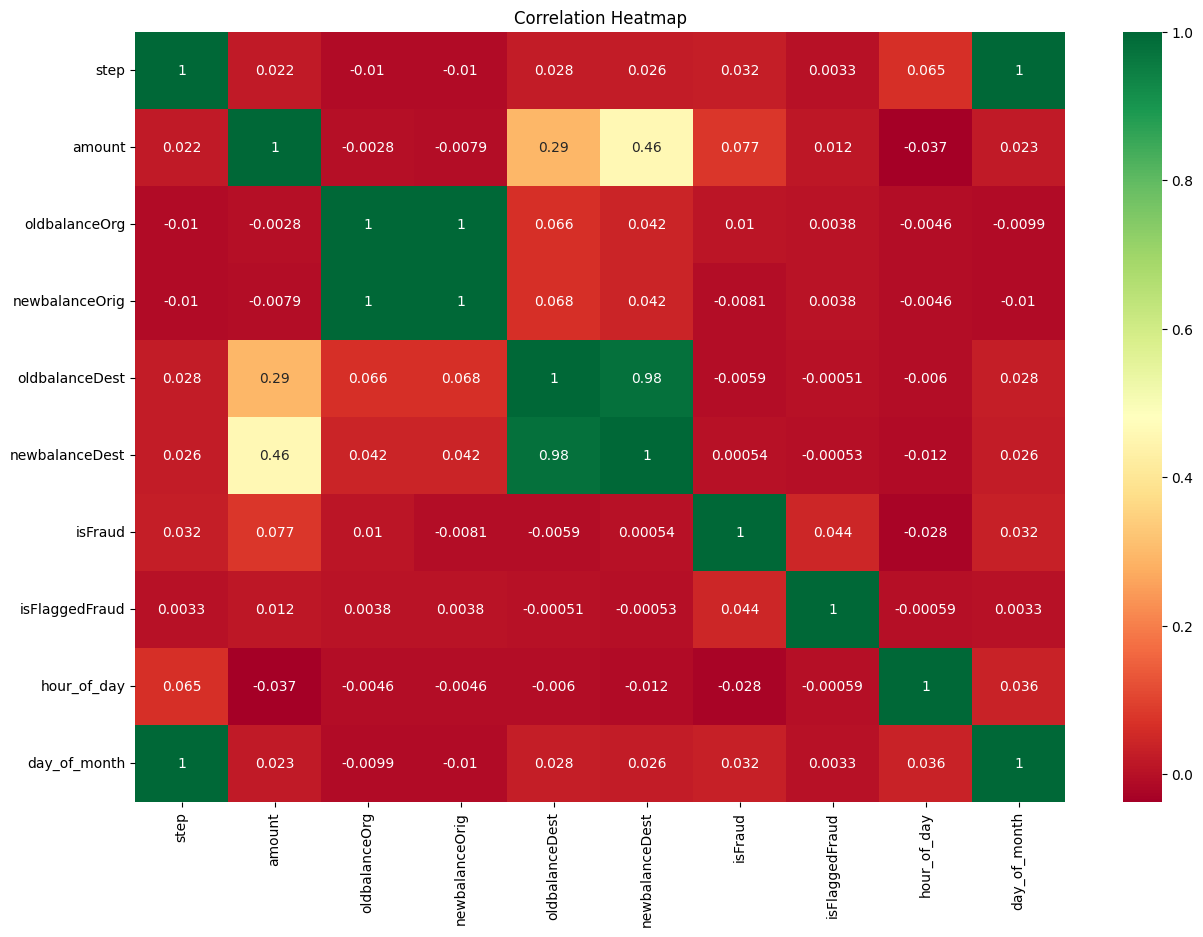

In [24]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap='RdYlGn')
plt.title("Correlation Heatmap")
plt.show()

#### Insights
No strong linear correlation with fraud

## Key Insights from EDA

1. Severe Class Imbalance
The dataset is highly imbalanced, with approximately 99.87% of transactions being legitimate and only 0.13% fraudulent. This reflects real-world financial systems but requires special handling during model building, such as resampling techniques and appropriate evaluation metrics.

2. Fraud Occurs Only in Specific Transaction Types
Fraudulent transactions are observed exclusively in TRANSFER and CASH_OUT transaction types. Other transaction types like PAYMENT, CASH_IN, and DEBIT show no fraud cases. This indicates that fraudsters typically transfer funds and then withdraw them.

3. High-Value Transactions Are More Prone to Fraud
Fraudulent transactions generally involve higher amounts compared to non-fraudulent ones. Fraud risk increases significantly with transaction value, especially in the 100K–1M and above 1M ranges.

4. Fraud Concentration in High Amount Buckets
When transaction amounts are grouped into buckets, fraud is almost non-existent in low-value transactions (<10K) and highly concentrated in higher-value buckets (>100K). This supports a risk-based transaction monitoring strategy.

5. Fraud Shows Strong Time-Based Patterns
Fraudulent activities peak during early morning hours (approximately 3 AM to 6 AM), with minimal activity during the rest of the day. This suggests that fraudsters exploit low-activity periods when monitoring is weaker.

6. Fraud Targets High-Balance Accounts
Fraudulent transactions tend to originate from accounts with higher balances, indicating that attackers focus on accounts with greater financial potential.

7. Suspicious Balance Behavior
Many transactions result in the sender’s balance dropping to zero, indicating account-draining behavior. While this aligns with fraud patterns, these balance features may introduce data leakage and should not be directly used in modeling.

8. Transaction Amount Distribution is Highly Skewed
The transaction amount distribution is heavily right-skewed, with most transactions being low-value and a small number of very high-value transactions. This highlights the importance of handling outliers and using transformations or binning.

9. No Strong Linear Relationship with Fraud
Correlation analysis shows no strong linear relationship between individual features and fraud. This indicates that fraud detection is a complex problem driven by interactions between multiple features rather than a single variable.

10. Multicollinearity in Balance Features
Strong correlations exist between balance-related features (oldbalanceOrg & newbalanceOrig, oldbalanceDest & newbalanceDest), indicating redundancy. These features need careful handling to avoid model instability.

11. Fraud is a Behavioral Pattern, Not a Single Event
Fraud is not driven by a single factor but by a combination of conditions such as high transaction amount, specific transaction types (TRANSFER/CASH_OUT), unusual time (early morning), and high account balances.

##  Data Preprocessing


### Feature Engineering
      Temporal features: hour_of_day, day_of_month, day_of_week
    - Behavioral flags: is_weekend, is_night, is_large_txn
    - Log-transformed amount: amount_log
    - Frequency features: sender_tx_freq, dest_tx_freq
   


In [27]:
df['hour_of_day'] = ((df['step'] - 1) % 24) + 1
df['day_of_month'] = (df['step'] - 1) // 24 + 1
df['day_of_week'] = ((df['step'] - 1) // 24) % 7

df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df['is_night'] = (
    (df['hour_of_day'] >= 22) | (df['hour_of_day'] <= 5)
).astype(int)

df['is_large_txn'] = (df['amount'] > 200000).astype(int) 
df['amount_log'] = np.log1p(df['amount'])


df['sender_tx_freq']  = df.groupby('nameOrig')['step'].transform('count')
df['dest_tx_freq']    = df.groupby('nameDest')['step'].transform('count')
df['is_round_amount'] = (df['amount'] % 1000 == 0).astype(int)

###  Encoding Categorical Variables (One-Hot Encoding)

In [25]:
df = pd.get_dummies(df, columns=['type','amount_bucket'], dtype='uint8')
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,...,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,amount_bucket_<1K,amount_bucket_1K-10K,amount_bucket_10K-100K,amount_bucket_100K-1M,amount_bucket_>1M
0,1,9839.640000,C1231006815,170136.000000,160296.360000,M1979787155,0.000000,0.000000,0,0,...,0,0,0,1,0,0,1,0,0,0
1,1,1864.280000,C1666544295,21249.000000,19384.720000,M2044282225,0.000000,0.000000,0,0,...,0,0,0,1,0,0,1,0,0,0
2,1,181.000000,C1305486145,181.000000,0.000000,C553264065,0.000000,0.000000,1,0,...,0,0,0,0,1,1,0,0,0,0
3,1,181.000000,C840083671,181.000000,0.000000,C38997010,21182.000000,0.000000,1,0,...,0,1,0,0,0,1,0,0,0,0
4,1,11668.140000,C2048537720,41554.000000,29885.860000,M1230701703,0.000000,0.000000,0,0,...,0,0,0,1,0,0,0,1,0,0


In [26]:
df.columns

Index(['step', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'hour_of_day', 'day_of_month', 'type_CASH_IN',
       'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER',
       'amount_bucket_<1K', 'amount_bucket_1K-10K', 'amount_bucket_10K-100K',
       'amount_bucket_100K-1M', 'amount_bucket_>1M'],
      dtype='object')

### Dropping Irrelevant / Leaky Columns

In [28]:
drop_cols = [
    'nameOrig', 'nameDest',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'isFlaggedFraud','step','type_CASH_IN','type_DEBIT',
    'type_PAYMENT'
]

df = df.drop(columns=drop_cols)


In [29]:
df.head()

,amount,isFraud,hour_of_day,day_of_month,type_CASH_OUT,type_TRANSFER,amount_bucket_<1K,amount_bucket_1K-10K,amount_bucket_10K-100K,amount_bucket_100K-1M,amount_bucket_>1M,day_of_week,is_weekend,is_night,is_large_txn,amount_log,sender_tx_freq,dest_tx_freq,is_round_amount
0,9839.640000,0,1,1,0,0,0,1,0,0,0,0,0,1,0,9.194276,1,1,0
1,1864.280000,0,1,1,0,0,0,1,0,0,0,0,0,1,0,7.531166,1,1,0
2,181.000000,1,1,1,0,1,1,0,0,0,0,0,0,1,0,5.204007,1,44,0
3,181.000000,1,1,1,1,0,1,0,0,0,0,0,0,1,0,5.204007,1,41,0
4,11668.140000,0,1,1,0,0,0,0,1,0,0,0,0,1,0,9.364703,1,1,0


### Feature Engineering

1. Time-Based Feature Extraction
The 'step' variable was transformed into more interpretable time-based features:
- 'hour_of_day' to capture hourly transaction patterns
- 'day_of_month' to identify trends across the month
- 'day_of_week' to capture weekly patterns

These features were created because EDA showed that fraud occurrences vary significantly across different time periods, especially during early morning hours.

2. Weekend and Night Indicators
Two binary features were created:
- 'is_weekend' to indicate weekend transactions
- 'is_night' to capture transactions occurring during late-night/early-morning hours

These features help identify unusual transaction timings, as fraud was observed to peak during low-activity periods.

3. Transaction Size Features
- 'is_large_txn' was created to flag transactions above 200,000, based on business rules and dataset definition of suspicious transactions
- 'amount_log' was applied to normalize the highly skewed transaction amount distribution

These transformations help the model better capture the risk associated with high-value transactions.

4. Customer Behavior Features
- 'sender_tx_freq': Number of transactions initiated by the sender
- 'dest_tx_freq': Number of transactions received by the destination

These features capture user behavior patterns, which are useful in identifying anomalies and suspicious activities.

5. Pattern-Based Feature
- 'is_round_amount' was created to identify transactions with rounded values (multiples of 1000), which can sometimes indicate automated or suspicious behavior.

6. Removal of Irrelevant and Leakage-Prone Features
The following columns were dropped:
- 'nameOrig', 'nameDest' (unique identifiers with no predictive value)
- Balance-related features (oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest) to avoid data leakage
- 'isFlaggedFraud' as it is derived from business rules
- 'step' (replaced with engineered time features)
- Less relevant transaction type categories (CASH_IN, DEBIT, PAYMENT) as fraud was not observed in these types during EDA

This step ensures that the model focuses on meaningful and generalizable features.

### Train-Test Split

In [30]:
X=df.drop(columns=['isFraud'])
y=df['isFraud']

In [31]:
X.columns = X.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
X.columns

Index(['amount', 'hour_of_day', 'day_of_month', 'type_CASH_OUT',
       'type_TRANSFER', 'amount_bucket_1K', 'amount_bucket_1K10K',
       'amount_bucket_10K100K', 'amount_bucket_100K1M', 'amount_bucket_1M',
       'day_of_week', 'is_weekend', 'is_night', 'is_large_txn', 'amount_log',
       'sender_tx_freq', 'dest_tx_freq', 'is_round_amount'],
      dtype='object')

##  Model Building


### Logistic Regression (Baseline Model)

In [35]:
log_model = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000,class_weight='balanced'))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42)), ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

### Random Forest Classifier

In [36]:
# rf = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=None,
#     class_weight='balanced',
#     random_state=42,
#     n_jobs=-1
# )



rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,            # control overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf_model = Pipeline([
    ('model', rf)
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=10, min_samples_leaf=5,
                                        min_samples_split=10, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

###  XGBoost Classifier

In [37]:
# xgb = XGBClassifier(
#     n_estimators=200,
#     max_depth=6,
#     learning_rate=0.1,
#     scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
#     eval_metric='logloss',
#     random_state=42,
#     n_jobs=-1
# )
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='aucpr',  # better for imbalance
    random_state=42,
    n_jobs=-1
)

xgb_model = Pipeline([
    ('model', xgb)
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.9, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='aucpr',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=8, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

### LightGBM Classifier

In [38]:

lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,              # same as XGB
    colsample_bytree=0.9,
    num_leaves=31,              # important for LGBM
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    objective='binary',
    metric='average_precision',   # equivalent to aucpr
    random_state=42,
    n_jobs=-1
)

lgbm_model = Pipeline([
    ('model', lgbm)
])

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 6570, number of negative: 5083526
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.230588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 697
[LightGBM] [Info] Number of data points in the train set: 5090096, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651247
[LightGBM] [Info] Start training from score -6.651247


Pipeline(steps=[('model',
                 LGBMClassifier(colsample_bytree=0.9, learning_rate=0.03,
                                max_depth=8, metric='average_precision',
                                n_estimators=300, n_jobs=-1, objective='binary',
                                random_state=42,
                                scale_pos_weight=773.7482496194825,
                                subsample=0.9))])


In this project, multiple machine learning models were used to detect fraudulent transactions. Since fraud detection is a classification problem with imbalanced data, models were selected based on their ability to handle non-linear relationships and class imbalance.

1. Logistic Regression (Baseline Model)
Logistic Regression was used as a baseline model to establish a reference point for performance. It provides a simple and interpretable approach but may struggle with complex patterns in the data.

2. Random Forest Classifier
Random Forest was used as it is an ensemble model capable of capturing non-linear relationships and interactions between features. It is robust to overfitting and performs well on structured data.

3. XGBoost Classifier
XGBoost was implemented due to its strong performance in classification problems and ability to handle imbalanced datasets effectively. It uses gradient boosting to improve prediction accuracy.

4. LightGBM Classifier
LightGBM was used for its efficiency and speed, especially with large datasets. It is capable of handling high-dimensional data and provides excellent performance in fraud detection tasks.

All models were trained using the processed dataset, and their performance was evaluated using appropriate metrics for imbalanced classification problems.

##  Model Evaluation

### Evaluation Metrics Used
    ROC-AUC, PR-AUC (better for imbalanced data)
    Precision, Recall, F1, F2
    Confusion Matrix

In [39]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    # threshold = 0.7  # or any value you want
    # y_prob = model.predict_proba(X_test)[:,1]
    # y_pred = (y_prob > threshold).astype(int)

    print("Classification Report:\n")
    print(classification_report(y_test, y_pred))

    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("PR-AUC:", average_precision_score(y_test, y_prob))
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # F1
    f1 = fbeta_score(y_test, y_pred, beta=1)

# F2
    f2 = fbeta_score(y_test, y_pred, beta=2)

    print("F1:", f1)
    print("F2:", f2)
    
    #Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[0])
    axes[0].set_title("Confusion Matrix")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr)
    axes[1].set_title("ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")

    # PR Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    axes[2].plot(recall, precision)
    axes[2].set_title("Precision-Recall Curve")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")

    plt.tight_layout()
    plt.show()

    return y_prob


Logistic Regression Performance
Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.84      0.91   1270881
           1       0.01      0.71      0.01      1643

    accuracy                           0.84   1272524
   macro avg       0.50      0.78      0.46   1272524
weighted avg       1.00      0.84      0.91   1272524

ROC-AUC: 0.8525611868895087
PR-AUC: 0.07883286875195722
F1: 0.01159517957662729
F2: 0.028296821565563977


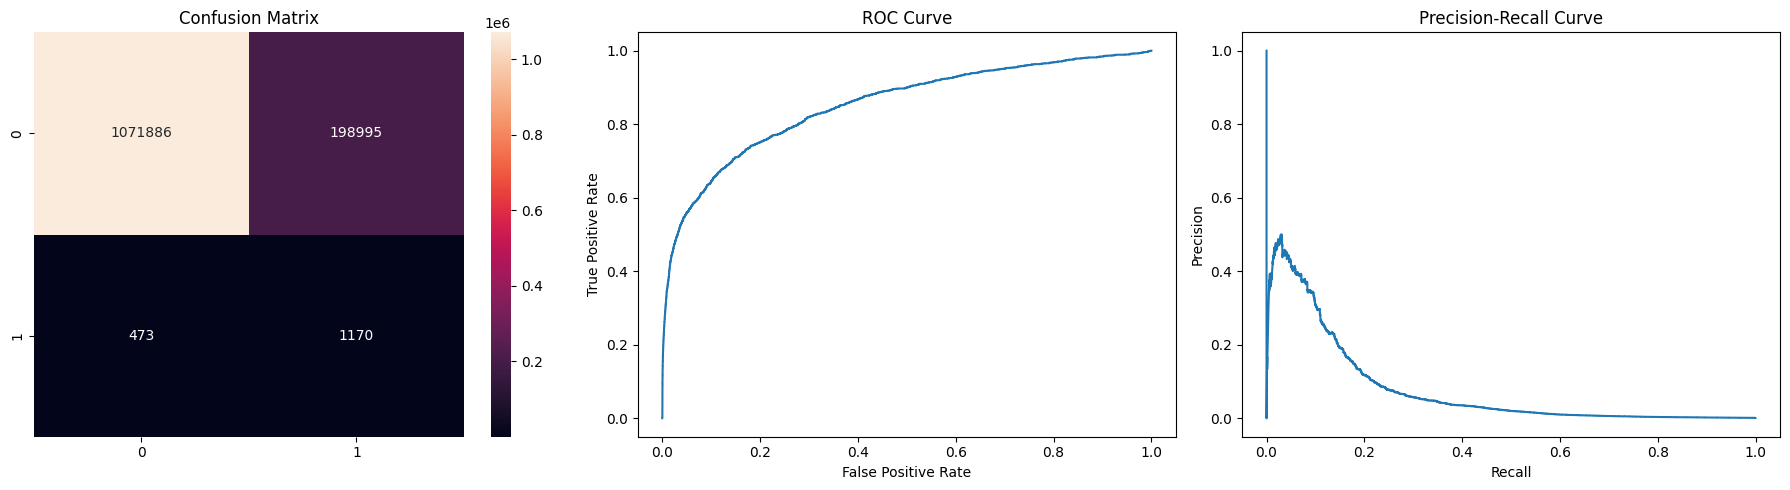

Random Forest Performance
Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.89      0.05      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.92      0.51   1272524
weighted avg       1.00      0.96      0.98   1272524

ROC-AUC: 0.9774187449895985
PR-AUC: 0.4737313674063782
F1: 0.04871271217650407
F2: 0.11249942010608192


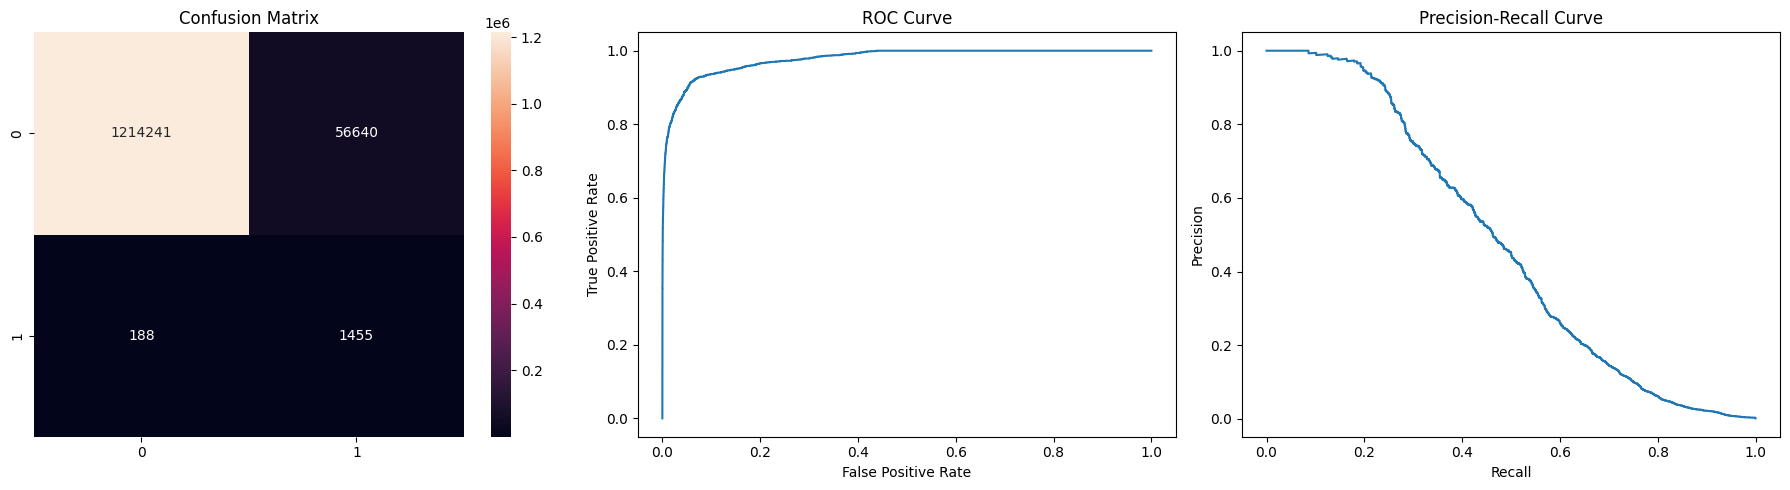

XGboost Performance
Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98   1270881
           1       0.03      0.89      0.07      1643

    accuracy                           0.97   1272524
   macro avg       0.52      0.93      0.52   1272524
weighted avg       1.00      0.97      0.98   1272524

ROC-AUC: 0.9819343189509309
PR-AUC: 0.6213287913935857
F1: 0.06644337829274917
F2: 0.14943909440723172


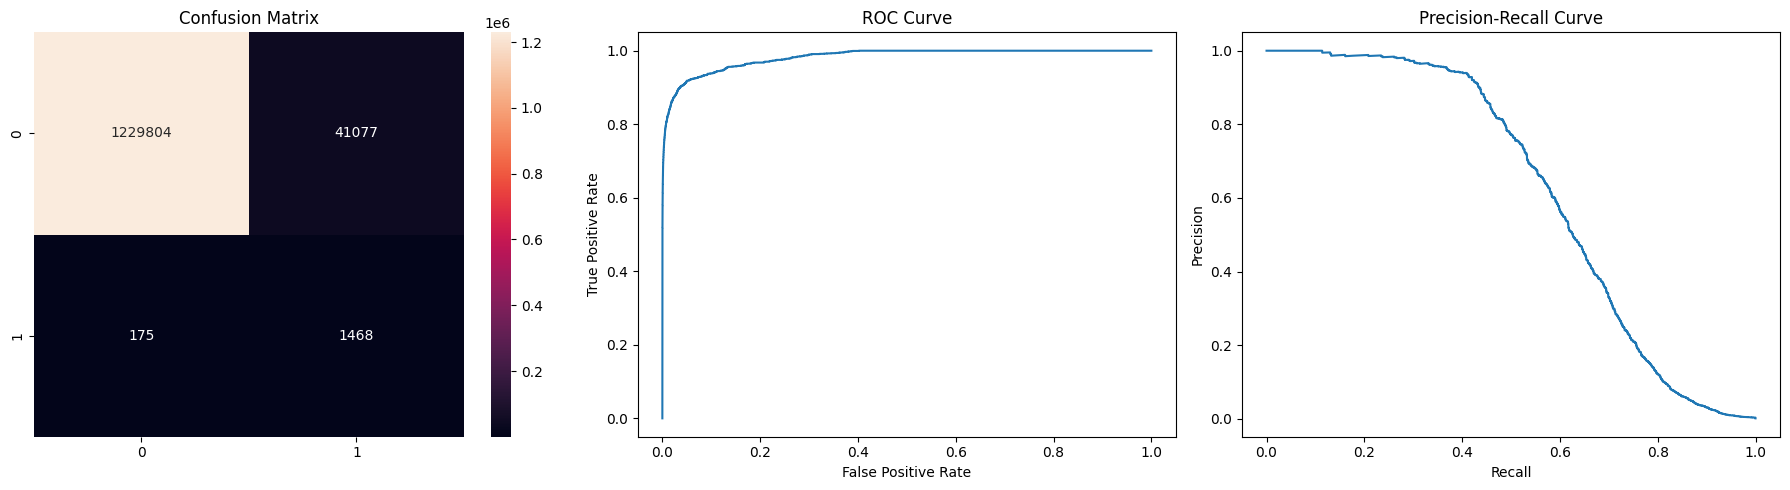

LGboost Performance
Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1270881
           1       0.02      0.86      0.04      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.90      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524

ROC-AUC: 0.9267105631689163
PR-AUC: 0.02205540563934442
F1: 0.039057870147052746
F2: 0.09143351228577327


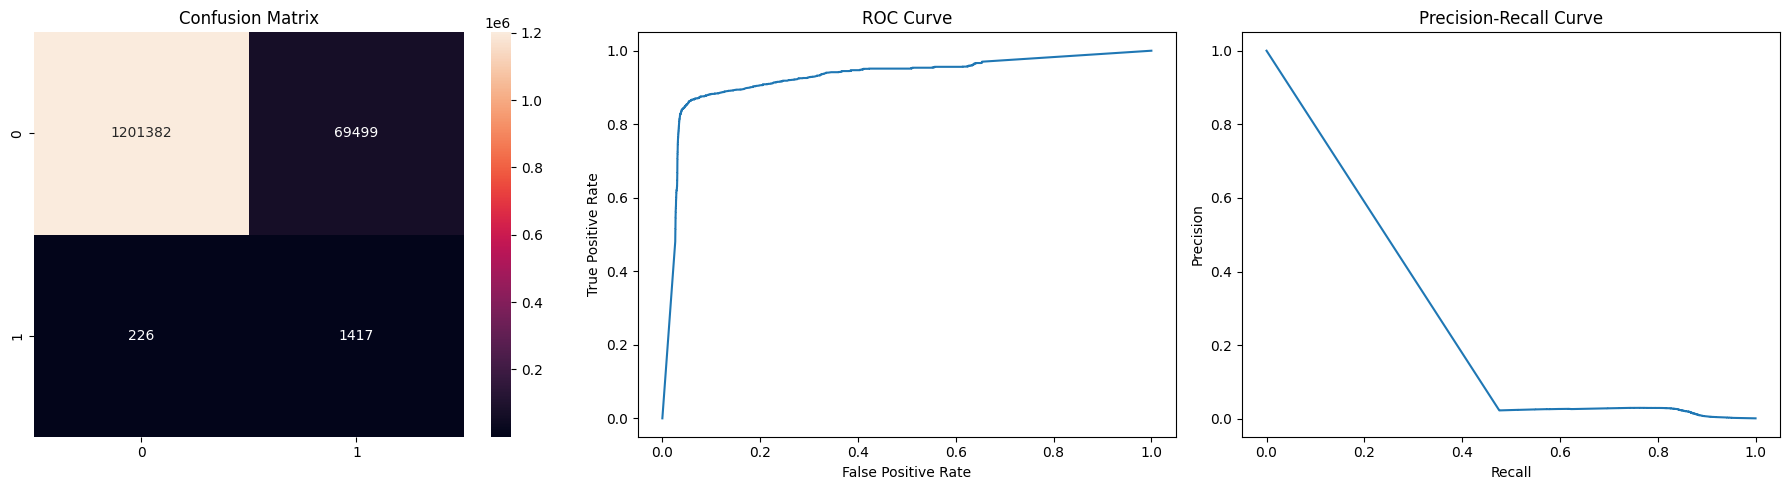

In [40]:
print("Logistic Regression Performance")
log_prob = evaluate_model(log_model, X_test, y_test)
print("Random Forest Performance")
rf_prob  = evaluate_model(rf_model, X_test, y_test)
print("XGboost Performance")
xgb_prob = evaluate_model(xgb_model, X_test, y_test)
print("LGboost Performance")
lgbm_prob = evaluate_model(lgbm_model, X_test, y_test)

## Model Evaluation Insights

1. Logistic Regression (Baseline Model)
The Logistic Regression model achieved a recall of 71% for fraud detection but had extremely low precision (~1%). This indicates that while it detects many fraud cases, it generates excessive false positives, making it less suitable for this problem.

2. Random Forest Performance
Random Forest improved performance significantly, achieving a recall of 89% with better precision (~3%). It also showed strong ROC-AUC (0.97) and PR-AUC (0.47), indicating its ability to capture complex patterns.

3. XGBoost Performance (Best Model)
XGBoost delivered the best performance with:
- Recall: 89%
- Highest ROC-AUC: 0.98
- Highest PR-AUC: 0.62

It provides the best balance between fraud detection and false positive control among all models.

4. LightGBM Performance
LightGBM achieved good recall (86%) but lower precision and PR-AUC, indicating comparatively weaker performance.

5. Accuracy is Misleading
All models show high accuracy (~95–97%) due to class imbalance. Accuracy is not a reliable metric for fraud detection.

6. Recall is Critical in Fraud Detection
Since missing fraud cases leads to financial loss, recall is prioritized. All tree-based models achieve high recall (>85%), which is desirable.

7. Precision is Low Across All Models
Precision remains very low (2–3%), meaning a large number of legitimate transactions are incorrectly flagged as fraud. This can negatively impact customer experience and operational efficiency.

8. Need for Threshold Optimization
By default, models classify transactions using a probability threshold of 0.5. However, this threshold is not optimal for imbalanced datasets.

To address low precision, threshold optimization is required to:
- Reduce false positives
- Improve precision
- Maintain an acceptable level of recall

Adjusting the threshold allows better control over the precision-recall tradeoff, enabling the model to be tuned based on business requirements.

9. ROC-AUC vs PR-AUC
While ROC-AUC scores are high for all models, PR-AUC is more meaningful for imbalanced datasets. XGBoost has the highest PR-AUC, confirming its superior performance.

10. Confusion Matrix Analysis
- Logistic Regression produces excessive false positives
- Tree-based models reduce false positives while maintaining high recall
- XGBoost provides the best tradeoff between detecting fraud and minimizing errors

11. Final Model Strategy
XGBoost is selected as the base model, and threshold tuning is applied to optimize performance based on business needs, balancing fraud detection (recall) and false alarm reduction (precision).

## Model Comparison

Comparison of all models based on performance metrics to select the best model.

In [43]:
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost','LGBoost'],
    'ROC-AUC': [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, lgbm_prob)
    ],
    'PR-AUC': [
        average_precision_score(y_test, log_prob),
        average_precision_score(y_test, rf_prob),
        average_precision_score(y_test, xgb_prob),
        average_precision_score(y_test, lgbm_prob)
    ],
    'Recall': [
        recall_score(y_test, log_model.predict(X_test)),
        recall_score(y_test, rf_model.predict(X_test)),
        recall_score(y_test, xgb_model.predict(X_test)),
        recall_score(y_test, lgbm_model.predict(X_test))
    ],
    'Precision': [
        precision_score(y_test, log_model.predict(X_test)),
        precision_score(y_test, rf_model.predict(X_test)),
        precision_score(y_test, xgb_model.predict(X_test)),
        precision_score(y_test, lgbm_model.predict(X_test))
    ]
})

display(results_df)

,Model,ROC-AUC,PR-AUC,Recall,Precision
0,Logistic Regression,0.852561,0.078833,0.712112,0.005845
1,Random Forest,0.977419,0.473731,0.885575,0.025045
2,XGBoost,0.981934,0.621329,0.893488,0.034505
3,LGBoost,0.926711,0.022055,0.862447,0.019981


### Threshold Optimization

#### Threshold Optimization — Random Forest

Best Threshold: 0.8869231359991572

After Threshold Optimization:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.37      0.54      0.44      1643

    accuracy                           1.00   1272524
   macro avg       0.69      0.77      0.72   1272524
weighted avg       1.00      1.00      1.00   1272524



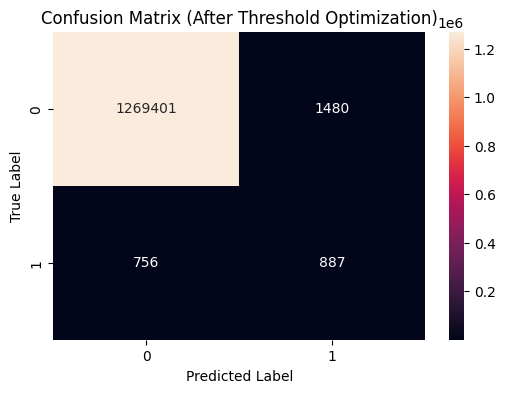

In [44]:
y_prob=rf_prob
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

# best_index = np.argmax(f1_scores[:-1])
# best_threshold = thresholds[best_index]

f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-8)

best_index = np.argmax(f2_scores[:-1])
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

y_pred_custom = (y_prob > best_threshold).astype(int)

print("\nAfter Threshold Optimization:")
print(classification_report(y_test, y_pred_custom))

cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix (After Threshold Optimization)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()



 #### Threshold Optimization — XGBoost

Best Threshold: 0.9727524

After Threshold Optimization:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.47      0.64      0.54      1643

    accuracy                           1.00   1272524
   macro avg       0.73      0.82      0.77   1272524
weighted avg       1.00      1.00      1.00   1272524



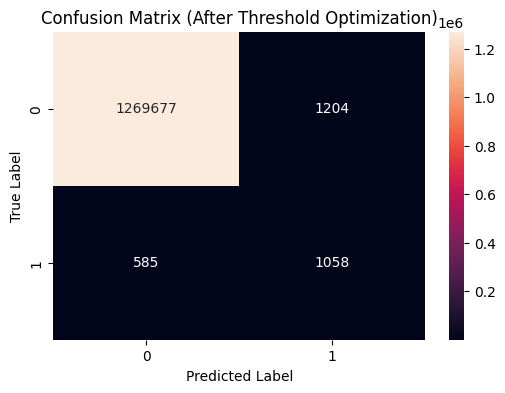

In [56]:
y_prob=xgb_prob
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

# best_index = np.argmax(f1_scores[:-1])
# best_threshold = thresholds[best_index]

f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-8)

best_index = np.argmax(f2_scores[:-1])
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

y_pred_custom = (y_prob > best_threshold).astype(int)

print("\nAfter Threshold Optimization:")
print(classification_report(y_test, y_pred_custom))

cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix (After Threshold Optimization)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()


#### Threshold Optimization — LightGBM

Best Threshold: 0.9750489362913786

After Threshold Optimization:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98   1270881
           1       0.03      0.77      0.06      1643

    accuracy                           0.97   1272524
   macro avg       0.51      0.87      0.52   1272524
weighted avg       1.00      0.97      0.98   1272524



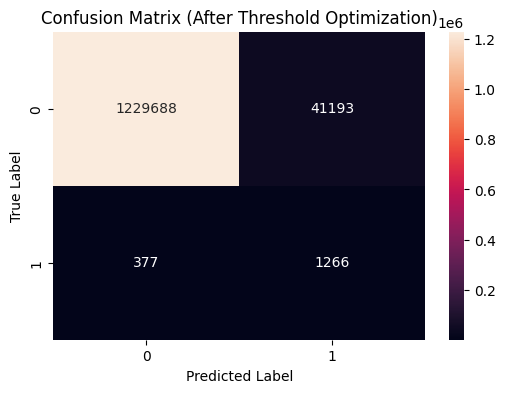

In [48]:
y_prob=lgbm_prob
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

# best_index = np.argmax(f1_scores[:-1])
# best_threshold = thresholds[best_index]

f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-8)

best_index = np.argmax(f2_scores[:-1])
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

y_pred_custom = (y_prob > best_threshold).astype(int)

print("\nAfter Threshold Optimization:")
print(classification_report(y_test, y_pred_custom))

cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix (After Threshold Optimization)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Threshold Optimization Insights

1. Improvement in Precision After Threshold Tuning
After applying threshold optimization, precision improved significantly:
- Random Forest: from ~3% → 37%
- XGBoost: from ~3% → 47%

This indicates a substantial reduction in false positives, improving the reliability of fraud alerts.

2. Controlled Trade-off Between Precision and Recall
While precision improved, recall decreased slightly:
- Random Forest recall: 89% → 54%
- XGBoost recall: 89% → 64%

This trade-off is expected, as increasing the threshold makes the model more conservative in predicting fraud.

3. XGBoost Remains the Best Model
After threshold tuning, XGBoost achieved:
- Precision: 47%
- Recall: 64%
- F1-score: 0.54

This provides the best balance between detecting fraud and minimizing false alarms.

4. Reduction in False Positives
Confusion matrix shows a significant drop in false positives:
- This improves customer experience
- Reduces operational workload for fraud investigation teams

5. Random Forest vs XGBoost
- Random Forest: Higher recall, lower precision
- XGBoost: Better balance of precision and recall

This highlights that XGBoost is more suitable for real-world deployment.

6. LightGBM Performance
LightGBM did not show significant improvement after threshold tuning, with very low precision (~3%), indicating it is less suitable for this use case.

7. Use of F2 Score for Optimization
Threshold was selected using F2 score, which prioritizes recall over precision. This aligns with the business goal of minimizing missed fraud cases while still improving precision.

8. Business Trade-off Strategy
Threshold tuning allows flexibility based on business needs:
- Lower threshold → Higher recall (catch more fraud, more false alarms)
- Higher threshold → Higher precision (fewer false alarms, may miss fraud)

9. Final Model Strategy
XGBoost with optimized threshold is selected as the final model, providing a balanced approach between fraud detection effectiveness and operational efficiency.

### Cross-Validation 

In [60]:
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# scores = cross_val_score(
#     best_model,
#     X_train,
#     y_train,
#     cv=skf,
#     scoring='roc_auc'
# )

# print("Cross-validated ROC-AUC:", scores.mean())


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

recalls = []
precisions = []
thresholds_used = []

for train_idx, val_idx in skf.split(X_train, y_train):

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train model
    xgb_model.fit(X_tr, y_tr)

    # Predict probabilities
    y_prob = xgb_model.predict_proba(X_val)[:, 1]

    # PR curve
    precision, recall, thresholds = precision_recall_curve(y_val, y_prob)

    # F2 score
    f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-8)

    best_idx = np.argmax(f2_scores[:-1])
    best_threshold = thresholds[best_idx]

    # Store threshold
    thresholds_used.append(best_threshold)

    # Predictions
    y_pred = (y_prob > best_threshold).astype(int)

    recalls.append(recall[best_idx])
    precisions.append(precision[best_idx])

print("Avg Recall:", np.mean(recalls))
print("Avg Precision:", np.mean(precisions))
print("Avg Threshold:", np.mean(thresholds_used))

Avg Recall: 0.6444444444444445
Avg Precision: 0.49057722506866375
Avg Threshold: 0.97255355


### Cross-Validation Insights

1. Model Stability Across Folds
Stratified K-Fold cross-validation was used to ensure that the model performance is consistent across different subsets of the data while maintaining class imbalance distribution.

The results show:
- Average Recall: ~64%
- Average Precision: ~49%

This indicates that the model performs consistently across different data splits and is not overfitting to a specific subset.

2. Consistent Threshold Selection
The average optimal threshold across folds is approximately 0.97, which is significantly higher than the default threshold of 0.5.

This confirms that a higher threshold is required to control false positives and improve precision in imbalanced datasets.

3. Balanced Precision-Recall Tradeoff
The model achieves a good balance between:
- Detecting fraud (recall ~64%)
- Reducing false alarms (precision ~49%)

This is a significant improvement compared to initial model results before threshold tuning.

4. Importance of Stratification
Stratified sampling ensures that each fold maintains the same fraud-to-non-fraud ratio, which is critical for reliable evaluation in highly imbalanced datasets.

5. Validation of Threshold Optimization Strategy
The cross-validation results confirm that threshold optimization using F2 score is stable and generalizable across different data splits.

6. Generalization Capability
The consistency in recall, precision, and threshold values across folds indicates that the model is robust and likely to perform well on unseen data.

7. Final Model Confidence
These results provide confidence in deploying the XGBoost model with the optimized threshold, as it demonstrates stable performance and balanced fraud detection capability.

 FEATURE IMPORTANCE

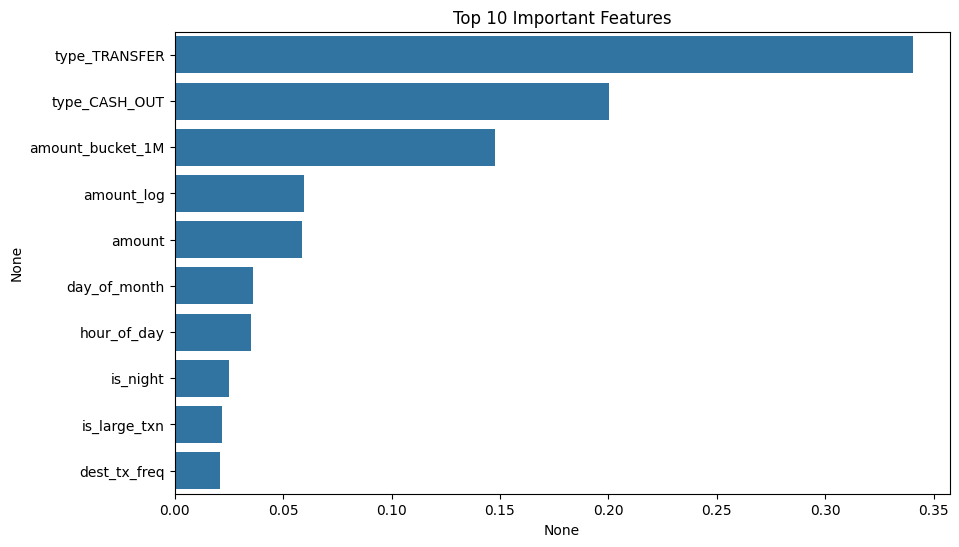

In [58]:
importances = pd.Series(
    best_model.named_steps['model'].feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances[:10], y=importances.index[:10])
plt.title("Top 10 Important Features")
plt.show()

#### Feature Importance Insights

Feature importance analysis shows that transaction type is the most influential factor in predicting fraud, with TRANSFER and CASH_OUT being the top contributors. This aligns with earlier EDA findings that fraud occurs primarily in these transaction types.

Transaction amount is also a key driver, with features like amount_bucket and log-transformed amount having high importance. This confirms that high-value transactions are more likely to be fraudulent.

Time-based features such as hour_of_day and is_night also contribute to the model, indicating that fraud is influenced by transaction timing.

Overall, the feature importance results validate the insights obtained during EDA and demonstrate that the model is learning meaningful and interpretable patterns.

Business Implications

## Business Impact Analysis

The fraud detection model provides significant value to financial institutions by improving both security and operational efficiency.

1. Financial Impact
By detecting fraudulent transactions with high recall, the model helps prevent financial losses caused by unauthorized transactions.

2. Operational Efficiency
The analysis identified that fraud is concentrated in specific transaction types and high-value transactions. This allows the business to focus monitoring efforts on high-risk scenarios, reducing unnecessary workload.

3. Customer Experience
Threshold optimization reduces false positives, ensuring that legitimate transactions are not unnecessarily blocked. This improves customer trust and satisfaction.

4. Risk-Based Monitoring
The model enables a tiered approach where high-value transactions and risky transaction types receive stricter checks, while low-risk transactions are processed smoothly.

5. Real-Time Decision Support
The model can be integrated into real-time systems to flag suspicious transactions instantly, enabling proactive fraud prevention.

6. Strategic Value
Insights from feature importance help businesses understand key fraud drivers, allowing them to design better fraud prevention policies and systems.

## Conclusion

This project successfully developed a fraud detection system using machine learning techniques. 

The analysis revealed that fraud is highly concentrated in specific transaction types (TRANSFER and CASH_OUT), high-value transactions, and unusual time periods. Based on these insights, advanced models such as XGBoost were used to detect fraudulent transactions effectively.

Threshold optimization significantly improved precision, reducing false positives while maintaining a reasonable recall. Cross-validation confirmed that the model is stable and generalizes well to unseen data.

Overall, the final model provides a balanced and reliable solution for detecting fraudulent transactions in financial systems.

## Business Recommendations

- Implement stricter checks for high-value transactions (>100K)
- Monitor TRANSFER and CASH_OUT transactions more closely
- Apply additional verification for transactions during early morning hours
- Use threshold-based alert systems to balance fraud detection and customer experience
- Deploy the model in real-time transaction systems for proactive fraud detection

## Future Work

- Incorporate real-time streaming data for live fraud detection
- Use advanced techniques like deep learning or anomaly detection
- Continuously retrain the model with new data to adapt to evolving fraud patterns
- Improve precision further using ensemble or hybrid models